In [1]:
# Import the libraries required for statistical analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

# Set a consistent style for visualizations
sns.set_theme(style="whitegrid")

In [3]:
# Load the heart disease dataset
df = pd.read_csv("heart.csv")

# Display the first five records
print("First five records:")
print(df.head())

# Display the dataset dimensions
print("\nDataset shape:")
print(df.shape)

# Display column names and data types
print("\nDataset information:")
df.info()

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check duplicate records
print("\nNumber of duplicate records:")
print(df.duplicated().sum())

First five records:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Dataset shape:
(303, 14)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps

In [4]:
# Generate descriptive statistics for numerical columns
print("Descriptive statistics:")
print(df.describe())

# Examine the distribution of chest pain categories
print("\nChest pain category counts:")
print(df["cp"].value_counts().sort_index())

# Examine the distribution of target categories
print("\nTarget category counts:")
print(df["target"].value_counts().sort_index())

# Examine the relationship between chest pain and target
print("\nContingency table:")
print(pd.crosstab(df["cp"], df["target"]))

Descriptive statistics:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.399340    0.729373   
std

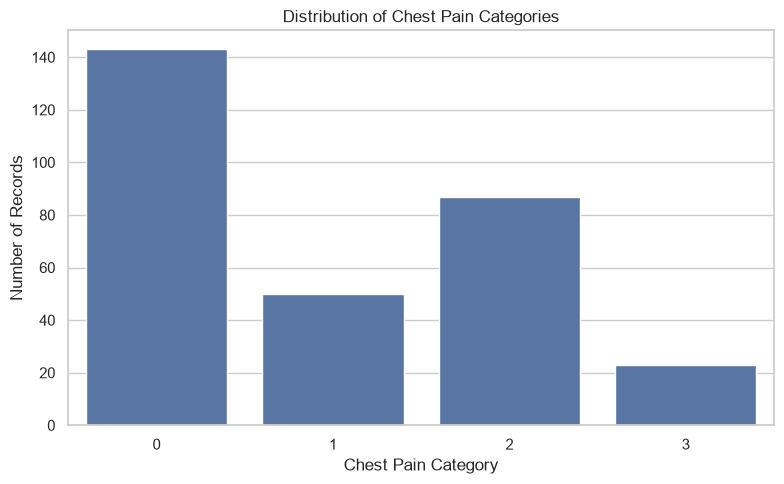

In [13]:
# Visualize the number of records in each chest pain category
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="cp")

plt.title("Distribution of Chest Pain Categories")
plt.xlabel("Chest Pain Category")
plt.ylabel("Number of Records")
plt.tight_layout()

plt.savefig(
    "figure/chest_pain_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

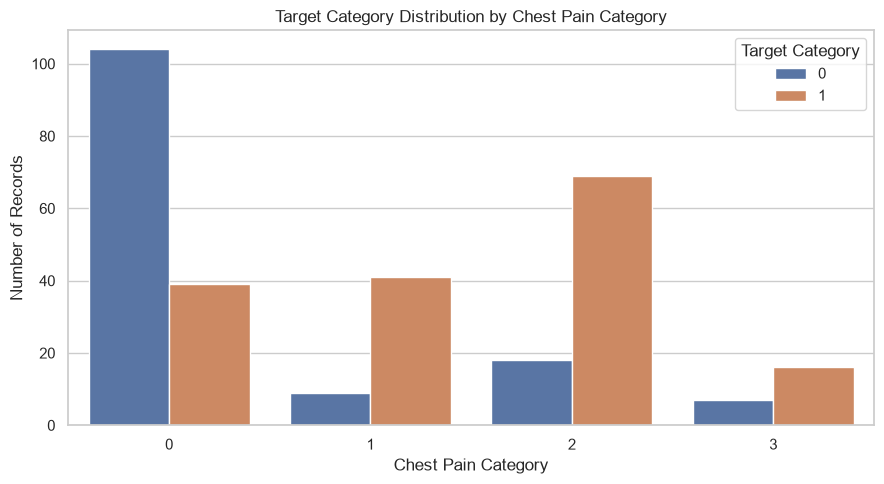

In [14]:
# Compare target-category counts across chest pain categories
plt.figure(figsize=(9, 5))

sns.countplot(data=df, x="cp", hue="target")

plt.title("Target Category Distribution by Chest Pain Category")
plt.xlabel("Chest Pain Category")
plt.ylabel("Number of Records")
plt.legend(title="Target Category")
plt.tight_layout()

plt.savefig(
    "figure/target_by_chest_pain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
# Create a contingency table for the two categorical variables
contingency_table = pd.crosstab(df["cp"], df["target"])

# Perform the chi-square test of independence
chi2_stat, p_value, degrees_freedom, expected = chi2_contingency(
    contingency_table
)

# Display the test results
print("Chi-square Test of Independence")
print("-" * 35)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {degrees_freedom}")
print(f"P-value: {p_value:.6f}")

# Display the expected frequencies
expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("\nExpected frequencies:")
print(expected_table.round(2))

# Check the expected-frequency assumption
if (expected < 5).any():
    print("\nWarning: At least one expected frequency is below 5.")
    print("Review the test assumptions before interpreting the result.")
else:
    print("\nAll expected frequencies are at least 5.")

Chi-square Test of Independence
-----------------------------------
Chi-square statistic: 81.6864
Degrees of freedom: 3
P-value: 0.000000

Expected frequencies:
target      0      1
cp                  
0       65.13  77.87
1       22.77  27.23
2       39.62  47.38
3       10.48  12.52

All expected frequencies are at least 5.


In [8]:
# Define the significance level
alpha = 0.05

print("Hypothesis Test Interpretation")
print("-" * 35)

if p_value < alpha:
    print("Reject the null hypothesis.")
    print(
        "The data provides statistically significant evidence "
        "of an association between chest pain category and target category."
    )
else:
    print("Fail to reject the null hypothesis.")
    print(
        "The data does not provide sufficient statistical evidence "
        "of an association between chest pain category and target category."
    )

Hypothesis Test Interpretation
-----------------------------------
Reject the null hypothesis.
The data provides statistically significant evidence of an association between chest pain category and target category.


In [9]:
# Calculate Cramér's V to estimate association strength
n = contingency_table.to_numpy().sum()

minimum_dimension = min(contingency_table.shape[0] - 1,
                        contingency_table.shape[1] - 1)

if n > 0 and minimum_dimension > 0:
    cramers_v = np.sqrt(
        chi2_stat / (n * minimum_dimension)
    )

    print(f"Cramér's V: {cramers_v:.4f}")
else:
    print("Cramér's V cannot be calculated for this table.")

Cramér's V: 0.5192


In [10]:
# Estimate a 95% bootstrap confidence interval for Cramér's V
rng = np.random.default_rng(42)
bootstrap_values = []

for _ in range(2000):
    # Sample rows with replacement
    sample_indices = rng.integers(0, len(df), size=len(df))
    sample = df.iloc[sample_indices]

    table = pd.crosstab(sample["cp"], sample["target"])

    # Skip degenerate tables
    if table.shape != contingency_table.shape:
        continue

    chi2_sample = chi2_contingency(table)[0]

    n_sample = table.to_numpy().sum()
    min_dim = min(table.shape[0] - 1, table.shape[1] - 1)

    if n_sample > 0 and min_dim > 0:
        v_sample = np.sqrt(chi2_sample / (n_sample * min_dim))
        bootstrap_values.append(v_sample)

# Calculate the confidence interval
if len(bootstrap_values) >= 1000:
    ci_lower, ci_upper = np.percentile(
        bootstrap_values, [2.5, 97.5]
    )

    print(f"Cramér's V: {cramers_v:.4f}")
    print(f"95% bootstrap CI: ({ci_lower:.4f}, {ci_upper:.4f})")
else:
    print("Too few valid bootstrap samples. Review the data and method.")

Cramér's V: 0.5192
95% bootstrap CI: (0.4302, 0.6193)


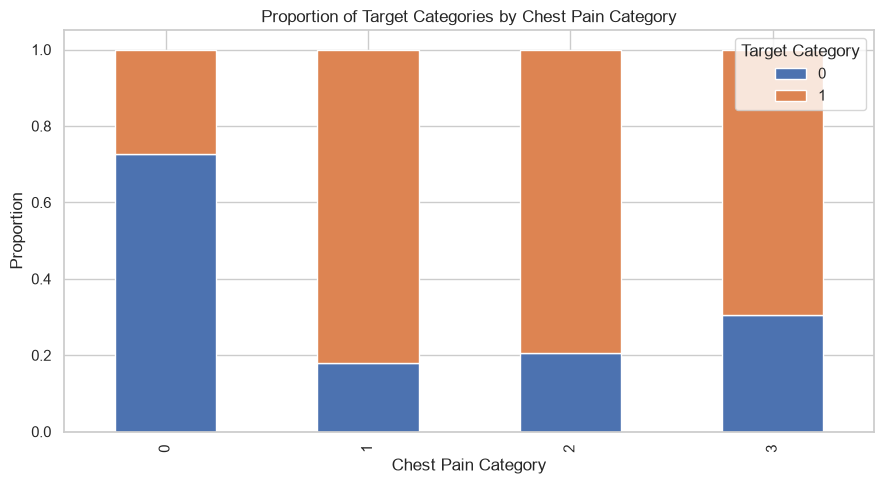

In [15]:
# Calculate target-category proportions within each chest pain category
proportions = pd.crosstab(
    df["cp"],
    df["target"],
    normalize="index"
)

# Create a stacked bar chart
proportions.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Proportion of Target Categories by Chest Pain Category")
plt.xlabel("Chest Pain Category")
plt.ylabel("Proportion")
plt.legend(title="Target Category")
plt.tight_layout()

plt.savefig(
    "figure/target_proportions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()